1-st order PF: Gate count = $r_{min}(2*N*\kappa + \mathrm{truncation~order}+1)= r_{min}(2*N+ 4)$

In [ ]:
# NCC_log.py第250行本应该传入q0和s0，错误传了s0两次
# 第249行也应该传入q0
import importlib
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import NCC_log as ncc_log

importlib.reload(ncc_log)
exact_log_total_error = ncc_log.exact_log_total_error
find_min_segments_log = ncc_log.find_min_segments_log

%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})
plt.rcParams["text.usetex"] = True

SAVE_PDF = False
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def fit_power_law(x, y):
    coeffs = np.polyfit(np.log(x), np.log(y), 1)
    slope = coeffs[0]
    prefactor = math.exp(coeffs[1])
    return slope, prefactor


def scaled_reference(x, y0, x0, exponent):
    return y0 * (x / x0) ** exponent




def gate_proxy(n, r_min, kappa=1.0):
    return r_min * (2.0 * kappa * n + 4.0)


def format_tick_labels(values):
    values = np.array(values, dtype=float)
    if np.allclose(values, np.round(values)):
        return [f"{int(round(val))}" for val in values]
    return [f"{val:.2f}".rstrip("0").rstrip(".") for val in values]


def plot_panel(ax, x, y, expected_exp, xlabel, title, invert_x=False, show_theory=True, x_tick_labels=None):
    slope, prefactor = fit_power_law(np.array(x, dtype=float), np.array(y, dtype=float))
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    fit = prefactor * x**slope

    ax.loglog(x, y, "o", ms=8, color="C0", label="data")
    if show_theory:
        ref = scaled_reference(x, y[0], x[0], expected_exp)
        ax.loglog(x, ref, "--", lw=2.0, color="C1", label=rf"theory slope ${expected_exp:.3f}$")
    ax.loglog(x, fit, ":", lw=2.2, color="C2", label=rf"fit slope ${slope:.3f}$")
    ax.xaxis.set_major_locator(mticker.FixedLocator(x))
    if x_tick_labels is None:
        x_tick_labels = format_tick_labels(x)
    ax.xaxis.set_major_formatter(mticker.FixedFormatter(x_tick_labels))
    ax.yaxis.set_major_locator(mticker.FixedLocator(y))
    ax.yaxis.set_major_formatter(mticker.FixedFormatter(format_tick_labels(y)))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    if invert_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel, fontsize=24)
    ax.set_ylabel("min gate count", fontsize=24)
    ax.set_title(title, fontsize=24)
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=True, fontsize=21)
    return slope


n_values = [4, 6, 8]
t_values = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
eps_values = [5e-2, 4e-2, 3e-2, 2.5e-2, 2e-2, 1.5e-2, 1e-2]

fixed_t_for_n = 1.0
fixed_eps_for_n = 1e-2
fixed_n_for_t = 4
fixed_eps_for_t = 1e-2
fixed_n_for_eps = 4
fixed_t_for_eps = 1.0
sampling = "weighted"


In [2]:
n_gate = []
for n in n_values:
    r_min, err = find_min_segments_log(n, fixed_t_for_n, fixed_eps_for_n, sampling=sampling)
    n_gate.append(gate_proxy(n, r_min))
    print(f"N sweep: N={n}, r_min={r_min}, err={err:.3e}, G_proxy={gate_proxy(n, r_min):.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
slope_n = plot_panel(ax, n_values, n_gate, 5 / 3, r"qubit number $N$", r"Trotter-LCU gate complexity versus qubit number $N$")
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / "plot_log_scaling_n.pdf", bbox_inches="tight")
print(f"fitted slope (N): {slope_n:.3f}")
plt.show()


N sweep: N=4, r_min=12, err=8.196e-03, G=48


KeyboardInterrupt: 

T sweep: T=0.5, r_min=5, err=7.806e-03, G_proxy=60.0
T sweep: T=0.75, r_min=8, err=9.301e-03, G_proxy=96.0
T sweep: T=1.0, r_min=12, err=8.196e-03, G_proxy=144.0
T sweep: T=1.5, r_min=20, err=8.518e-03, G_proxy=240.0
T sweep: T=2.0, r_min=28, err=9.591e-03, G_proxy=336.0
T sweep: T=3.0, r_min=47, err=9.786e-03, G_proxy=564.0
fitted slope (T): 1.257


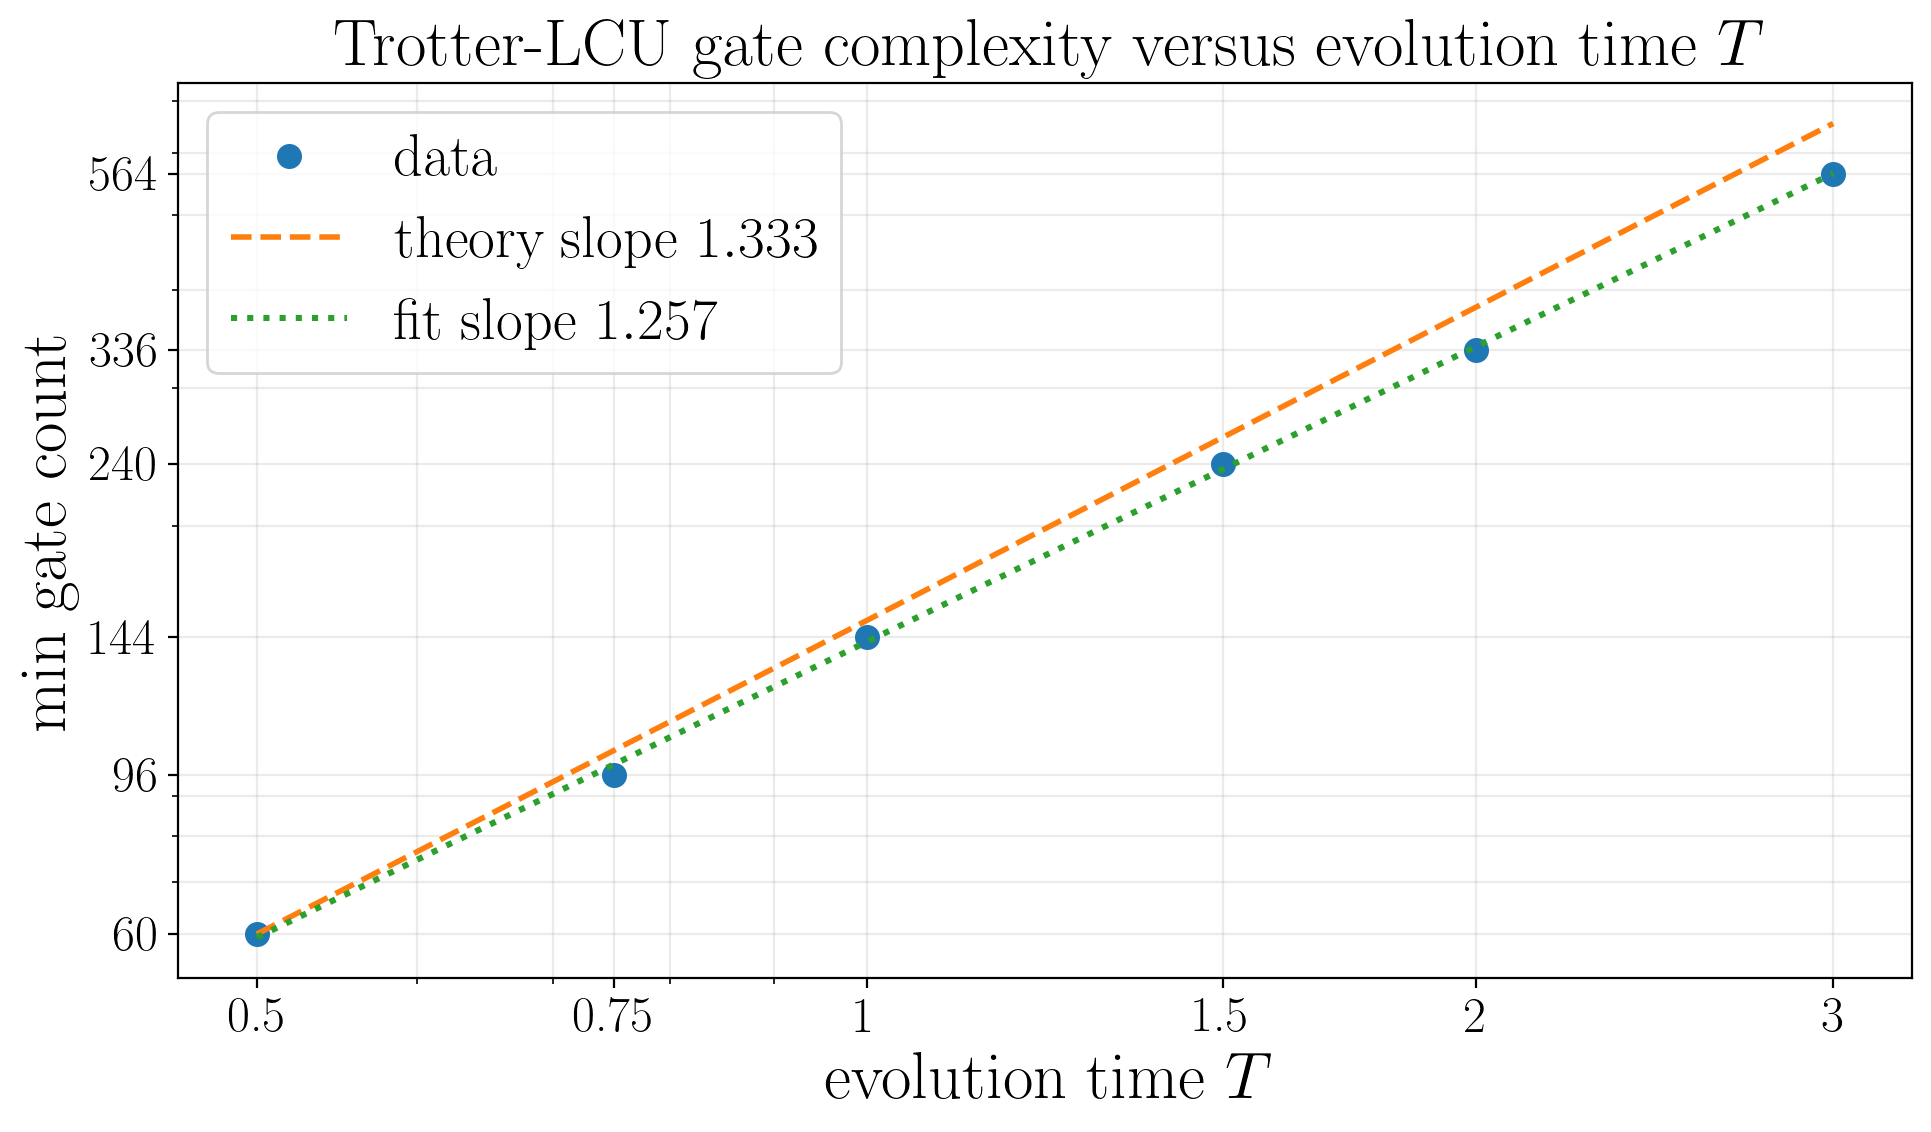

In [12]:
t_gate = []
for t_total in t_values:
    r_min, err = find_min_segments_log(fixed_n_for_t, t_total, fixed_eps_for_t, sampling=sampling)
    t_gate.append(gate_proxy(fixed_n_for_t, r_min))
    print(f"T sweep: T={t_total}, r_min={r_min}, err={err:.3e}, G_proxy={gate_proxy(fixed_n_for_t, r_min):.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
slope_t = plot_panel(ax, t_values, t_gate, 4 / 3, r"evolution time $T$", r"Trotter-LCU gate complexity versus evolution time $T$")
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / "plot_log_scaling_t.pdf", bbox_inches="tight")
print(f"fitted slope (T): {slope_t:.3f}")
plt.show()


eps sweep: eps=0.05, log(1/eps)=2.996, r_min=8, err=3.465e-02, G_proxy=96.0
eps sweep: eps=0.04, log(1/eps)=3.219, r_min=8, err=3.465e-02, G_proxy=96.0
eps sweep: eps=0.03, log(1/eps)=3.507, r_min=9, err=2.271e-02, G_proxy=108.0
eps sweep: eps=0.025, log(1/eps)=3.689, r_min=9, err=2.261e-02, G_proxy=108.0
eps sweep: eps=0.02, log(1/eps)=3.912, r_min=10, err=1.555e-02, G_proxy=120.0
eps sweep: eps=0.015, log(1/eps)=4.200, r_min=11, err=1.111e-02, G_proxy=132.0
eps sweep: eps=0.01, log(1/eps)=4.605, r_min=12, err=8.196e-03, G_proxy=144.0
fitted slope vs log(1/eps): 1.014


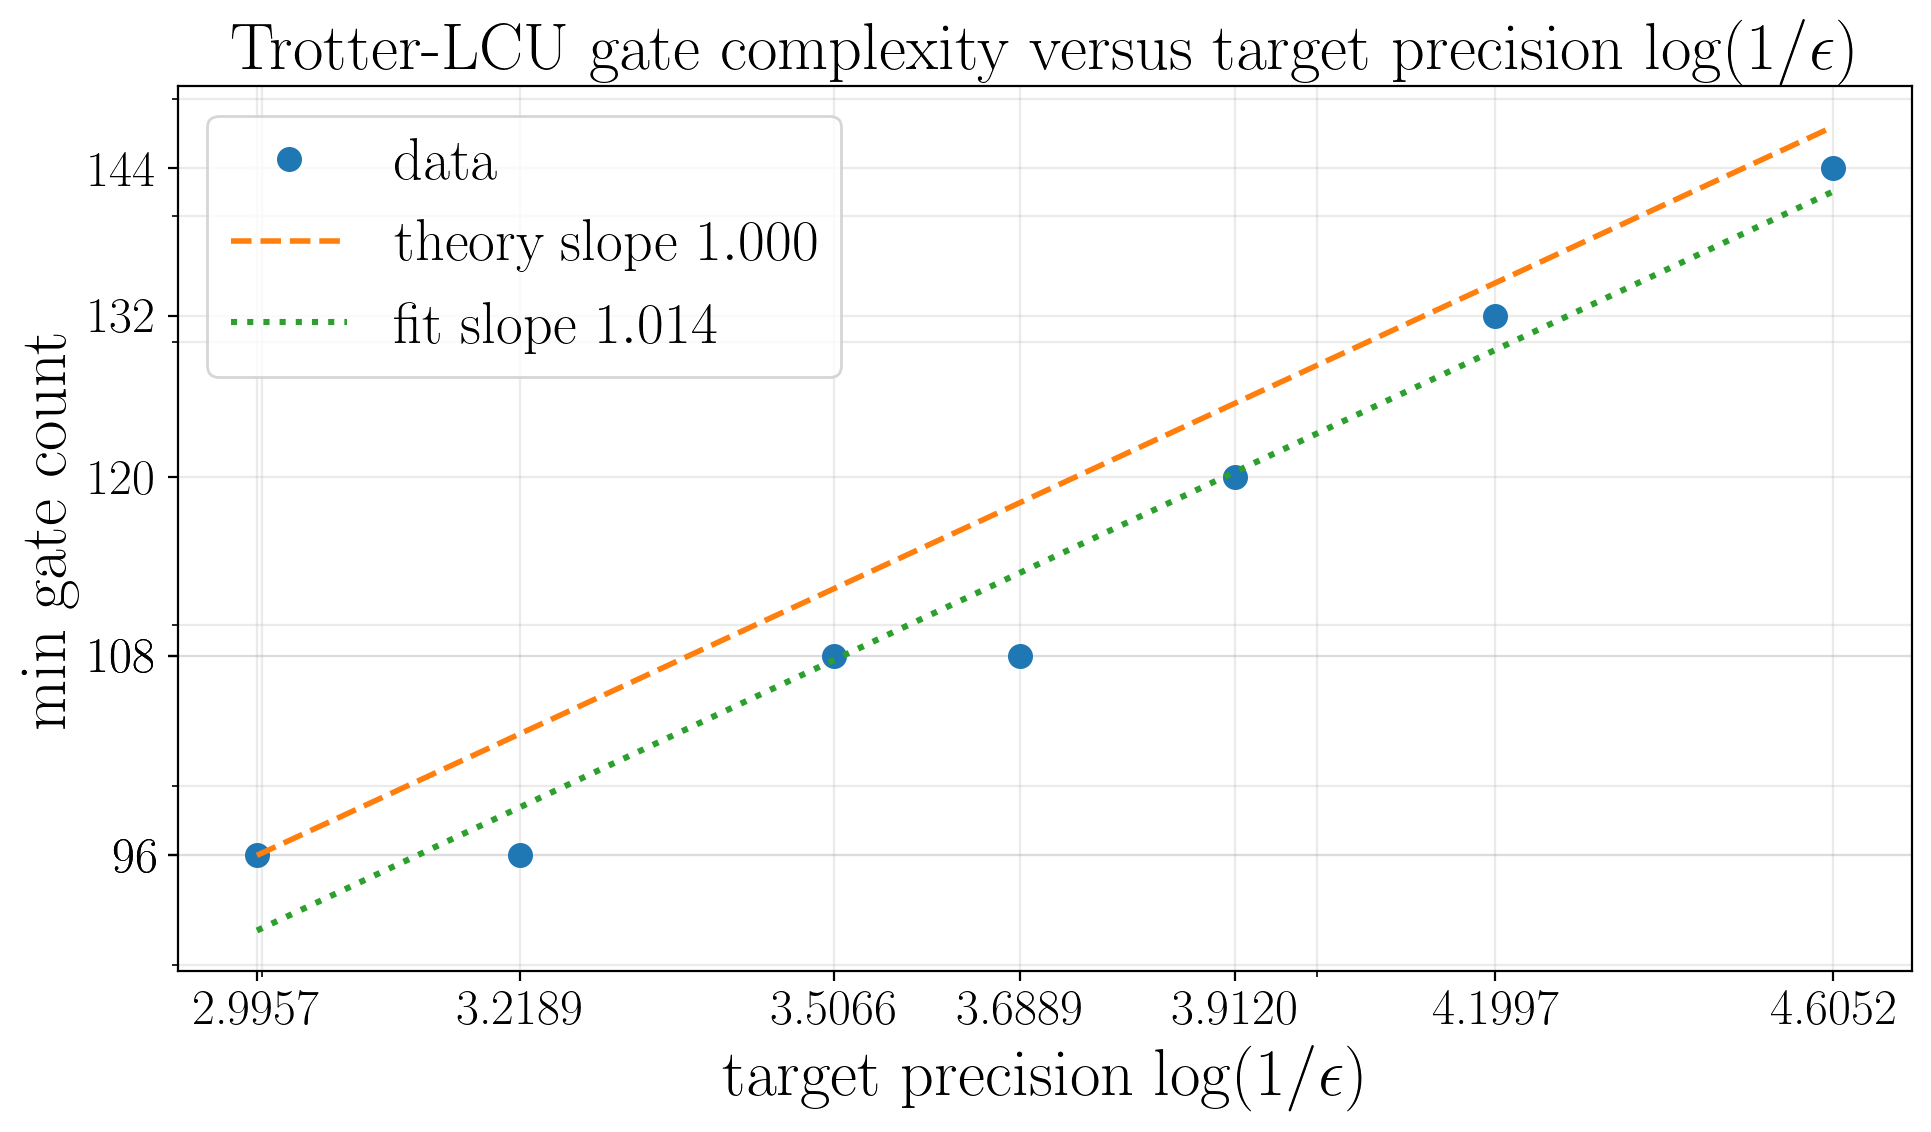

In [16]:
eps_gate = []
log_inv_eps = np.log(1 / np.array(eps_values, dtype=float))
for eps in eps_values:
    r_min, err = find_min_segments_log(fixed_n_for_eps, fixed_t_for_eps, eps, sampling=sampling)
    eps_gate.append(gate_proxy(fixed_n_for_eps, r_min))
    print(f"eps sweep: eps={eps}, log(1/eps)={math.log(1/eps):.3f}, r_min={r_min}, err={err:.3e}, G_proxy={gate_proxy(fixed_n_for_eps, r_min):.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
precision_tick_labels = [f"{val:.4f}" for val in log_inv_eps]
slope_eps = plot_panel(
    ax,
    log_inv_eps,
    eps_gate,
    1.0,
    r"target precision $\log(1/\epsilon)$",
    r"Trotter-LCU gate complexity versus target precision $\log(1/\epsilon)$",
    x_tick_labels=precision_tick_labels,
)
fig.tight_layout()
if SAVE_PDF:
    fig.savefig(FIG_DIR / "plot_log_scaling_eps.pdf", bbox_inches="tight")
print(f"fitted slope vs log(1/eps): {slope_eps:.3f}")
plt.show()
